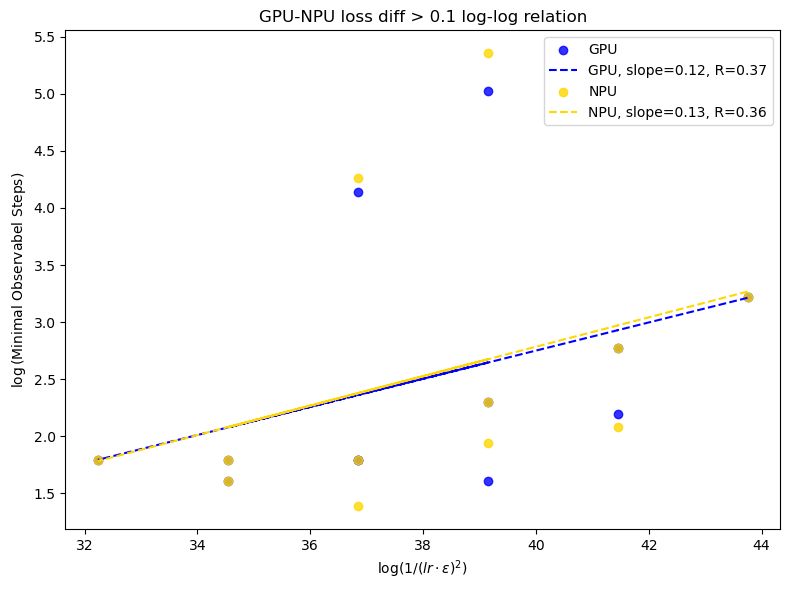

GPU回归参数: LinregressResult(slope=0.12321387055714195, intercept=-2.177538359112354, rvalue=0.37191642233174715, pvalue=0.23387099216378135, stderr=0.0972493688490972, intercept_stderr=3.7077445574182106)
NPU回归参数: LinregressResult(slope=0.12889509232040908, intercept=-2.3712601356125282, rvalue=0.3568311004761207, pvalue=0.2548697097269757, stderr=0.10670851972590356, intercept_stderr=4.06838561448973)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 可配置的阈值
threshold = 0.1  # 可选0.05/0.1/0.2

# 加载数据
df_gpu = pd.read_csv('summary_GPU_lr_scan.csv')
df_npu = pd.read_csv('summary_NPU_lr_scan.csv')

def compute_observable_steps(df, threshold):
    df_both = df[(df['error_mode'] == 'both') & (df['layer_types'].isin(['none', None]))]
    df_none = df[(df['error_mode'] == 'none') & (df['layer_types'].isin(['[]', None]))]
    loss_cols = [col for col in df.columns if col.startswith('loss_iter_')]
    results = []
    for lr in sorted(df_both['learning_rate'].unique()):
        for eps in sorted(df_both['forward_eps'].unique()):
            base_rows = df_none[df_none['learning_rate'] == lr]
            if len(base_rows) == 0:
                continue
            base_mean = base_rows[loss_cols].mean().values
            rows = df_both[(df_both['learning_rate'] == lr) & (df_both['forward_eps'] == eps)]
            if len(rows) == 0:
                continue
            both_mean = rows[loss_cols].mean().values
            loss_diff = both_mean - base_mean
            step = np.argmax(loss_diff > threshold) if np.any(loss_diff > threshold) else np.nan
            results.append({'learning_rate': lr, 'eps': eps, 'observable_steps': step})
    results_df = pd.DataFrame(results)
    results_df['product_lr_eps'] = results_df['learning_rate'] * results_df['eps']
    return results_df.dropna()

# 计算可观测步数表
gpu_steps = compute_observable_steps(df_gpu, threshold)
npu_steps = compute_observable_steps(df_npu, threshold)

# log-log 拟合与可视化
def plot_loglog_steps(gpu_steps, npu_steps):
    plt.figure(figsize=(8,6))
    # GPU
    x_gpu = -2 * np.log(gpu_steps['product_lr_eps'])
    y_gpu = np.log(gpu_steps['observable_steps'])
    plt.scatter(x_gpu, y_gpu, color='blue', label='GPU', alpha=0.8)
    reg_gpu = linregress(x_gpu, y_gpu)
    plt.plot(x_gpu, reg_gpu.slope*x_gpu + reg_gpu.intercept, color='blue', linestyle='--', label=f'GPU, slope={reg_gpu.slope:.2f}, R={reg_gpu.rvalue:.2f}')

    # NPU
    x_npu = -2 * np.log(npu_steps['product_lr_eps'])
    y_npu = np.log(npu_steps['observable_steps'])
    plt.scatter(x_npu, y_npu, color='gold', label='NPU', alpha=0.8)
    reg_npu = linregress(x_npu, y_npu)
    plt.plot(x_npu, reg_npu.slope*x_npu + reg_npu.intercept, color='gold', linestyle='--', label=f'NPU, slope={reg_npu.slope:.2f}, R={reg_npu.rvalue:.2f}')

    plt.xlabel(r'$\log(1/(lr \cdot \epsilon)^2)$')
    plt.ylabel(r'$\log$(Minimal Observabel Steps)')
    plt.title(f'GPU-NPU loss diff > {threshold} log-log relation')
    plt.legend()
    plt.tight_layout()
    plt.show()
    # 返回回归参数以便补论文用
    return reg_gpu, reg_npu

reg_gpu, reg_npu = plot_loglog_steps(gpu_steps, npu_steps)
print('GPU回归参数:', reg_gpu)
print('NPU回归参数:', reg_npu)
